In [1]:
import os

os.chdir("..")

# Enable on-disk caching of torch.compile Triton/CUDA kernels.  Must be set
# before the first torch import so inductor picks it up at module-load time.
os.environ.setdefault("TORCHINDUCTOR_FX_GRAPH_CACHE", "1")

# Must be set before the first CUDA allocation.  Lets PyTorch's allocator back
# non-contiguous virtual memory segments, preventing the 1 GiB fragmentation OOM
# that hits the refiner at 512×512 (320-ch intermediate, expand_ratio=16).
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import drjit as dr
import mitsuba as mi

mi.set_variant("cuda_ad_latent16")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.benchmark as bench

from config import load_config
from latents.mi_vae import MiVae
from networks import NetworkManager
from renderers import RendererManager
from testing.dr_timer import DrTimer
from utils.plugin_utils import register_plugins

/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


In [2]:
cff = "configs/runs/ablation/Lamp-1024-Best.yaml"
cfg = load_config(cff)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = cfg["dtype"]
torch_dtype = torch.float16 if dtype == "half" else torch.float32

mi_vae = MiVae(model_name=cfg["model_id"], dtype=torch_dtype, device=device)
register_plugins(cfg)

rgb_res    = cfg["image_resolution"]   # 1024
rgb_ch     = 3
latent_ch  = mi_vae.latent_channels()
latent_res = mi_vae.latent_resolution(rgb_res)  # 128

print(f"RGB res: {rgb_res}, latent res: {latent_res}, latent channels: {latent_ch}")

# Build the baseline RendererManager (128×128 latents).
# This establishes the main sensor and loads the scene.
renderers = RendererManager(
    cfg,
    rgb_res=1024,
    rgb_ch=rgb_ch,
    latent_res=latent_res,
    latent_ch=latent_ch,
)

# Determine AOV channel count by running one test render.
aov_ch = (
    renderers.aov.render(renderers.rgb.scene, renderers.rgb.params).shape[1]
    if cfg["use_aovs"]
    else 0
)
print(f"AOV channels: {aov_ch}")

nets = NetworkManager(cfg, device, latent_ch, aov_ch)

/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


RGB res: 1024, latent res: 128, latent channels: 16
Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
AOV channels: 4


In [3]:
# torch._dynamo.reset()  # Uncomment only when you need to force full recompilation

SCENE_CKPT   = Path("outputs/Lamp-1024-Best/scene.pt")
REFINER_CKPT = Path("outputs/Lamp-1024-Best/refiner.pt")

renderers.load_scene_checkpoint(SCENE_CKPT)
nets.load_checkpoint(REFINER_CKPT)
nets.eval()

# ── Toggle ────────────────────────────────────────────────────────────────────
# True  → tiled decode: compiles inner decoder+post_quant_conv (fixed tile size,
#          compile once); enables 512×512 latent without OOM.
# False → full decode:  compiles entire vae.decode per resolution (faster compile,
#          more fusion); 512 excluded (4096×4096 intermediate OOMs without tiling).
TILED_DECODE = False
# ─────────────────────────────────────────────────────────────────────────────

mi_vae.vae = mi_vae.vae.half()

if TILED_DECODE:
    mi_vae.vae.enable_tiling()
    # Tile input to decoder is always tile_latent_min_size×tile_latent_min_size
    # regardless of overall latent resolution, so dynamic=False is valid and
    # these compiled kernels are reused across all resolutions in the sweep.
    mi_vae.vae.decoder = torch.compile(
        mi_vae.vae.decoder, dynamic=False, mode="max-autotune-no-cudagraphs"
    )
    # SD3.5 VAE has post_quant_conv=None — guard to avoid torch.compile(None)
    # returning a decorator fn that breaks diffusers' `if not None` check.
    if mi_vae.vae.post_quant_conv is not None:
        mi_vae.vae.post_quant_conv = torch.compile(
            mi_vae.vae.post_quant_conv, dynamic=False, mode="max-autotune-no-cudagraphs"
        )
else:
    mi_vae.vae.disable_tiling()
    # Channels-last improves conv throughput (NHWC avoids transpositions).
    # Must be set before torch.compile so the layout is baked into the traced graph.
    mi_vae.vae = mi_vae.vae.to(memory_format=torch.channels_last)
    # Full vae.decode compiled fresh per resolution inside run_at_latent_res,
    # with results cached in _decoder_cache to avoid recompilation across re-runs.

# In-memory cache: lat_res → compiled decode fn.  Persists for the kernel
# session; combined with the on-disk FX graph cache (TORCHINDUCTOR_FX_GRAPH_CACHE)
# this means torch.compile only runs once per resolution per machine.
_decoder_cache: dict = {}

print(f"Checkpoints loaded.  TILED_DECODE={TILED_DECODE}")

Checkpoints loaded.  TILED_DECODE=False


In [4]:
import gc
import types

from training.train_manager import TrainingManager


@torch.no_grad()
def run_at_latent_res(lat_res: int, gt_spp: int = 64, ref_spp: int = 1024) -> dict:
    """Run the full latent pipeline at `lat_res` and collect images + per-stage timings.

    Images returned
    ---------------
    decoded_raw  : VAE decode of the raw latent render
    decoded_ref  : VAE decode after neural refinement
    rgb          : `gt_spp` straight RGB render  (noisy comparison, matched SPP)
    ref          : `ref_spp` straight RGB render  (fully-converged reference GT)

    Timing convention (mirrors pipeline.py::time_forward)
    -------------------------------------------------------
    Mitsuba renders  →  DrTimer(warmup=0)          — data render acts as warmup
    PyTorch ops      →  bench.Timer.timeit(1).mean — ms

    Notes
    -----
    - Both Mitsuba renders use `gt_spp` so latent vs RGB timing is directly comparable.
    - VAE decode time scales quadratically with lat_res (8× upscale → 64× pixels at 512).
    - `ref_spp` should be scaled down with increasing resolution (constant total sample
      budget); the sweep cell handles this automatically.
    """
    rgb_out_res = lat_res * mi_vae.vae_scale_factor

    # drjit wavefront limit: total samples must be strictly < 2^32.
    # e.g. 4096×4096 × 256 = exactly 2^32, which fails the check — cap to 255.
    _max_spp = (2**32 - 1) // (rgb_out_res * rgb_out_res)
    gt_spp = min(gt_spp, _max_spp)

    # --- free old Mitsuba scenes to avoid a 2× peak during reset_renderers ---
    renderers.rgb    = None
    renderers.latent = None
    renderers.aov    = None
    gc.collect()
    torch.cuda.empty_cache()

    renderers.latent_res = lat_res
    renderers.rgb_res    = rgb_out_res
    renderers.aov_res    = lat_res
    renderers.reset_renderers()
    renderers.load_scene_checkpoint(SCENE_CKPT)
    renderers.set_optimizable_parameters(TrainingManager.SCENE_OPTIMIZATION_TARGETS)
    nets.load_checkpoint(REFINER_CKPT)
    nets.eval()

    _opt = renderers.get_scaled_opt_params()

    # Offload VAE while Mitsuba renders to free several GB
    mi_vae.vae.to("cpu")
    torch.cuda.empty_cache()

    # ---- latent render ---------------------------------------------------
    renderers.latent.set_spp(gt_spp)
    with dr.suspend_grad():
        latent_raw_gpu, _ = renderers.latent.render(seed=0, opt_params=_opt)  # data + implicit warmup
        latent_raw = latent_raw_gpu.float().cpu()
        del latent_raw_gpu
    latent_time_ms = DrTimer(lambda: renderers.latent.render(seed=0, opt_params=_opt), warmup=0).timeit(1)
    torch.cuda.empty_cache()

    # ---- AOVs ------------------------------------------------------------
    with dr.suspend_grad():
        aovs_gpu = renderers.aov.render(renderers.rgb.scene, renderers.latent.params, seed=0)

    # ---- refine ----------------------------------------------------------
    torch.cuda.empty_cache()
    _lat_gpu = latent_raw.to(device)
    latent_ref_gpu, _ = nets.refine_latent_conv(_lat_gpu, aovs_gpu)  # data + implicit warmup
    latent_ref = latent_ref_gpu.float().cpu()
    del latent_ref_gpu
    refine_time_ms = bench.Timer(
        stmt="nets.refine_latent_conv(lat, aovs)",
        globals={"nets": nets, "lat": _lat_gpu, "aovs": aovs_gpu},
    ).timeit(1).mean * 1e3
    del aovs_gpu, _lat_gpu
    torch.cuda.empty_cache()

    # ---- comparison RGB render (gt_spp, matched to latent) ---------------
    rgb = None
    rgb_time_ms = None
    try:
        renderers.rgb.set_spp(gt_spp)
        with dr.suspend_grad():
            rgb_gpu = renderers.rgb.render(seed=0, denoiser=False)   # data + implicit warmup
            rgb = rgb_gpu.float().cpu()
            del rgb_gpu
        rgb_time_ms = DrTimer(
            lambda: renderers.rgb.render(seed=0, denoiser=False), warmup=0
        ).timeit(1)
        torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError as e:
        print(f"  RGB ({gt_spp} SPP) OOM at {rgb_out_res}×{rgb_out_res}: {e}")

    # ---- fully-converged reference render (ref_spp) ----------------------
    ref = None
    try:
        renderers.rgb.set_spp(ref_spp)
        with dr.suspend_grad():
            ref_gpu = renderers.rgb.render(seed=0, denoiser=False)
            ref = ref_gpu.float().cpu()
            del ref_gpu
        torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError as e:
        print(f"  Ref ({ref_spp} SPP) OOM at {rgb_out_res}×{rgb_out_res}: {e}")

    # ---- decode ----------------------------------------------------------
    mi_vae.vae.to(device)
    torch.cuda.empty_cache()

    if TILED_DECODE:
        # decoder and post_quant_conv already compiled at checkpoint time with
        # fixed tile shapes — reuse those compiled kernels. Restore the original
        # MiVae.decode wrapper so the tiled_decode path is used (undoes any
        # patching from a previous untiled run without kernel restart).
        mi_vae.decode = types.MethodType(MiVae.decode, mi_vae)
    else:
        # Reuse the compiled decoder for this resolution if we've seen it before
        # (in-memory cache); otherwise compile and store it.  The on-disk FX graph
        # cache (TORCHINDUCTOR_FX_GRAPH_CACHE=1) means even a fresh kernel restart
        # skips retracing — inductor loads the saved Triton kernels directly.
        if lat_res not in _decoder_cache:
            _vae_decode = mi_vae.vae.decode

            @torch.compile(dynamic=False, fullgraph=True, mode="max-autotune")
            def _compiled_decode(z):
                return _vae_decode(z).sample

            _decoder_cache[lat_res] = _compiled_decode
            print(f"  Compiled decoder for lat_res={lat_res} (cached for this session)")
        else:
            _compiled_decode = _decoder_cache[lat_res]
            print(f"  Reusing cached decoder for lat_res={lat_res}")

        def _decode(latents):
            latents = latents / mi_vae.scaling_factor
            if mi_vae.shift_factor is not None:
                latents = latents + mi_vae.shift_factor
            latents = latents.to(dtype=mi_vae.vae.dtype, device=mi_vae.vae.device)
            image = _compiled_decode(latents)
            if mi_vae.is_qwen_model or mi_vae.is_wan_model:
                image = image.squeeze(2)
            return mi_vae.image_processor.postprocess(image, output_type="pt")

        mi_vae.decode = _decode

    # Warmup: in tiled mode, triggers inner decoder compilation on first call
    # (tile-size is fixed, so this is reused across resolutions after the first).
    # In untiled mode, triggers full vae.decode compilation for this shape
    # and records the CUDA graph.
    _ = mi_vae.decode(latent_raw)
    del _
    torch.cuda.empty_cache()

    decoded_raw = mi_vae.decode(latent_raw).float().cpu()
    decode_time_ms = bench.Timer(
        stmt="mi_vae.decode(lat).float().cpu()",
        globals={"mi_vae": mi_vae, "lat": latent_raw},
    ).timeit(1).mean * 1e3
    torch.cuda.empty_cache()

    decoded_ref = mi_vae.decode(latent_ref).float().cpu()
    torch.cuda.empty_cache()

    return {
        "latent_res":     lat_res,
        "rgb_res":        rgb_out_res,
        # images
        "latent_raw":     latent_raw,
        "latent_ref":     latent_ref,
        "decoded_raw":    decoded_raw,
        "decoded_ref":    decoded_ref,
        "rgb":            rgb,
        "ref":            ref,
        # timings (ms)
        "latent_time_ms": latent_time_ms,
        "refine_time_ms": refine_time_ms,
        "decode_time_ms": decode_time_ms,
        "rgb_time_ms":    rgb_time_ms,
        # metadata
        "gt_spp":         gt_spp,
        "ref_spp":        ref_spp,
    }

In [5]:
# ── Sanity check: run the trained resolution before the full sweep ─────────────
# run_at_latent_res handles reset_renderers + load_scene_checkpoint +
# set_optimizable_parameters internally, so this is fully self-contained.
# print("Running sanity check at trained resolution (128×128 latent → 1024×1024 RGB)...")
# _diag = run_at_latent_res(latent_res, gt_spp=64, ref_spp=512)

# def _hw(t):
#     if t is None: return None
#     return t[0].permute(1,2,0)[...,:3].clamp(0,1).numpy() if t.ndim == 4 else t.permute(1,2,0)[...,:3].clamp(0,1).numpy()

# fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
# panels = [
#     (_diag['ref'],          f'Converged Ref (512 SPP)'),
#     (_diag['rgb'],          f'RGB 64 SPP'),
#     (_diag['decoded_raw'],  f'Latent Decoded Raw (64 SPP)'),
#     (_diag['decoded_ref'],  f'Latent Decoded Refined (64 SPP)'),
# ]
# for ax, (img, title) in zip(axes, panels):
#     if img is None:
#         ax.text(0.5, 0.5, 'OOM', ha='center', va='center', transform=ax.transAxes)
#     else:
#         ax.imshow(_hw(img))
#     ax.set_title(title, fontsize=10)
#     ax.set_xticks([]);  ax.set_yticks([])

# plt.suptitle(f'Sanity Check  |  128×128 latent  (sigmoid opt_params={bool(renderers.scene_opt_params)})', fontsize=11)
# plt.tight_layout();  plt.show()
# del _diag
# torch.cuda.empty_cache()
# print('Sanity check done.')

In [6]:
GT_SPP = 255 if TILED_DECODE else 256   # SPP for latent render and comparison RGB (matched for fair timing)

def max_ref_spp(rgb_res: int) -> int:
    """Largest (2^n - 1) SPP before hitting Mitsuba's uint32 total-sample limit.

    The limit scales as SPP × pixels ≤ 2^32, so each halving of resolution
    (quarter the pixels) adds 2 to the exponent, quadrupling max SPP:

      512×512   →  2^14 - 1 = 16383
      1024×1024 →  2^12 - 1 =  4095
      2048×2048 →  2^10 - 1 =  1023
      4096×4096 →   2^8 - 1 =   255
    """
    n = 32 - 2 * int(round(np.log2(rgb_res)))
    return 2**n - 1

# 64 = control (below trained res), 128 = trained baseline, 256/512 = super-res.
# 512 only included in tiled mode — untiled 512 requires 4096×4096 intermediate
# which OOMs; tiled mode handles it by processing in fixed-size chunks.
# 1024 excluded in both modes: crashes OptiX denoiser (tensor size > uint32 max).
RESOLUTIONS = [64, 128, 256, 512] if TILED_DECODE else [64, 128, 256]

results = {}
for r in RESOLUTIONS:
    rgb_r     = r * mi_vae.vae_scale_factor
    ref_spp_r = max_ref_spp(rgb_r)
    print(f"\n--- Latent {r}×{r}  →  RGB {rgb_r}×{rgb_r}  (ref SPP: {ref_spp_r}) ---")
    try:
        results[r] = run_at_latent_res(r, gt_spp=GT_SPP, ref_spp=ref_spp_r)
        res = results[r]
        print(f"  decoded_raw       : {res['decoded_raw'].shape}")
        print(f"  decoded_ref       : {res['decoded_ref'].shape}")
        print(f"  rgb  ({GT_SPP:5d} spp) : {res['rgb'].shape if res['rgb'] is not None else 'OOM'}")
        print(f"  ref  ({ref_spp_r:5d} spp) : {res['ref'].shape if res['ref'] is not None else 'OOM'}")
    except torch.cuda.OutOfMemoryError as e:
        print(f"  Entire run OOM: {e}")
        results[r] = None

print("\nDone.")


--- Latent 64×64  →  RGB 512×512  (ref SPP: 16383) ---
Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
  Compiled decoder for lat_res=64 (cached for this session)
  decoded_raw       : torch.Size([1, 3, 512, 512])
  decoded_ref       : torch.Size([1, 3, 512, 512])
  rgb  (  256 spp) : torch.Size([1, 3, 512, 512])
  ref  (16383 spp) : torch.Size([1, 3, 512, 512])

--- Latent 128×128  →  RGB 1024×1024  (ref SPP: 4095) ---
Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
  Compiled decoder for lat_res=128 (cached for this session)
  decoded_raw       : torch.Size([1, 3, 1024, 1024])
  decoded_ref       : torch.Size([1, 3, 1024, 1024])
  rgb  (  256 spp) : torch.Size([1, 3, 1024, 1024])
  ref  ( 4095 spp) : torch.Size([1, 3, 1024, 1024])

--- Latent 256×256  →  RGB 2048×2048  (ref SPP: 1023) ---
Need 3 custom emitters.
Need 18 custom BSDFs.
Need 13 SPDs for this scene.
  Compiled decoder for lat_res=256 (cached for this session)
  decod

In [ ]:
# ── SR timing bar chart ───────────────────────────────────────────────────────
# Styling matches the panel of the same name in equal_comparison.ipynb, which
# composes this chart with the equal-error ones into the combined paper figure.
F = 1.35                      # font scale (see equal_comparison.ipynb)
PANEL_W, PANEL_H = 7.0, 6.0   # panel size, shared with the combined figure

plt.rcParams.update({
    "font.family": "serif",
    "font.serif":  ["Times New Roman", "Times"],
    "font.size":       18 * F,
    "axes.titlesize":  20 * F,
    "axes.labelsize":  18 * F,
    "xtick.labelsize": 18 * F,
    "ytick.labelsize": 18 * F,
    "legend.fontsize": 18 * F,
})

valid_timing = [(r, results[r]) for r in RESOLUTIONS if results.get(r) is not None]

print('Super-resolution equal-SPP timing:')
for r, res in valid_timing:
    total_lat = res["latent_time_ms"] + res["refine_time_ms"] + res["decode_time_ms"]
    rgb_t = res["rgb_time_ms"] if res["rgb_time_ms"] is not None else 0
    print(f'  {r}×{r}→{res["rgb_res"]}×{res["rgb_res"]}  '
          f'Latent: {res["latent_time_ms"]:.0f}+{res["refine_time_ms"]:.0f}+{res["decode_time_ms"]:.0f}'
          f'={total_lat:.0f} ms  |  RGB: {rgb_t:.0f} ms')
print()

# Resolutions are split between tick labels and the axis label: at the shared
# panel width the full 'Latent 128×128 → 1024×1024 RGB' does not fit.
labels       = [f"{r}×{r}\n→ {res['rgb_res']}×{res['rgb_res']}"
                for r, res in valid_timing]
lat_times    = [res["latent_time_ms"]  for _, res in valid_timing]
refine_times = [res["refine_time_ms"]  for _, res in valid_timing]
decode_times = [res["decode_time_ms"]  for _, res in valid_timing]
rgb_times    = [res["rgb_time_ms"] if res["rgb_time_ms"] is not None else 0
                for _, res in valid_timing]
total_lat    = [l + r + d for l, r, d in zip(lat_times, refine_times, decode_times)]

x       = np.arange(len(labels))
width   = 0.35   # the pair in a group meets at x = xi
bar_pad = 0.02   # keeps the two labels of a pair from touching

fig, ax = plt.subplots(figsize=(PANEL_W + 0.8, PANEL_H))  # +y-label width

ax.bar(x - width / 2, lat_times,    width, color="C0")
ax.bar(x - width / 2, refine_times, width, color="C2", bottom=lat_times)
ax.bar(x - width / 2, decode_times, width, color="C3",
       bottom=[l + r for l, r in zip(lat_times, refine_times)])
b_rgb = ax.bar(x + width / 2, rgb_times, width, color="C1")

ax.set_ylim(0, max(total_lat + rgb_times) * 1.45)

# Latent label ends at the pair's shared edge, RGB label starts there, so
# neither can run into the other.
for xi, tot in zip(x, total_lat):
    ax.text(xi - bar_pad, tot * 1.005, f"{tot:.0f} ms",
            ha="right", va="bottom", fontsize=16 * F)
for xi, h in zip(x, rgb_times):
    if h > 0:
        ax.text(xi + bar_pad, h * 1.005, f"{h:.0f} ms",
                ha="left", va="bottom", fontsize=16 * F)

ax.set_xticks(x)
ax.set_xticklabels(labels, ha="center")
ax.tick_params(axis="x", labelsize=16 * F)
ax.set_title(f"Equal SPP ({GT_SPP} SPP each)", fontsize=20 * F, fontweight="bold")
ax.set_xlabel("Latent → RGB Resolution", fontweight="bold")
ax.xaxis.set_label_coords(0.5, -0.30)   # matches equal_comparison.ipynb's XLABEL_Y
ax.set_ylabel("Time (ms)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/superresolution_timing.png", dpi=150, bbox_inches="tight")
plt.show()


Super-resolution image grid metrics (raw MSE over [0,1]):
  64×64→512×512:
    Decoded (raw): LPIPS 0.391  /  MSE 0.0143
    Decoded (refined): LPIPS 0.251  /  MSE 0.0090
    256-SPP RGB: LPIPS 0.321  /  MSE 0.0003
  128×128→1024×1024:
    Decoded (raw): LPIPS 0.381  /  MSE 0.0134
    Decoded (refined): LPIPS 0.225  /  MSE 0.0076
    256-SPP RGB: LPIPS 0.272  /  MSE 0.0003


  256×256→2048×2048:
    Decoded (raw): LPIPS 0.502  /  MSE 0.0130
    Decoded (refined): LPIPS 0.428  /  MSE 0.0079
    256-SPP RGB: LPIPS 0.136  /  MSE 0.0004


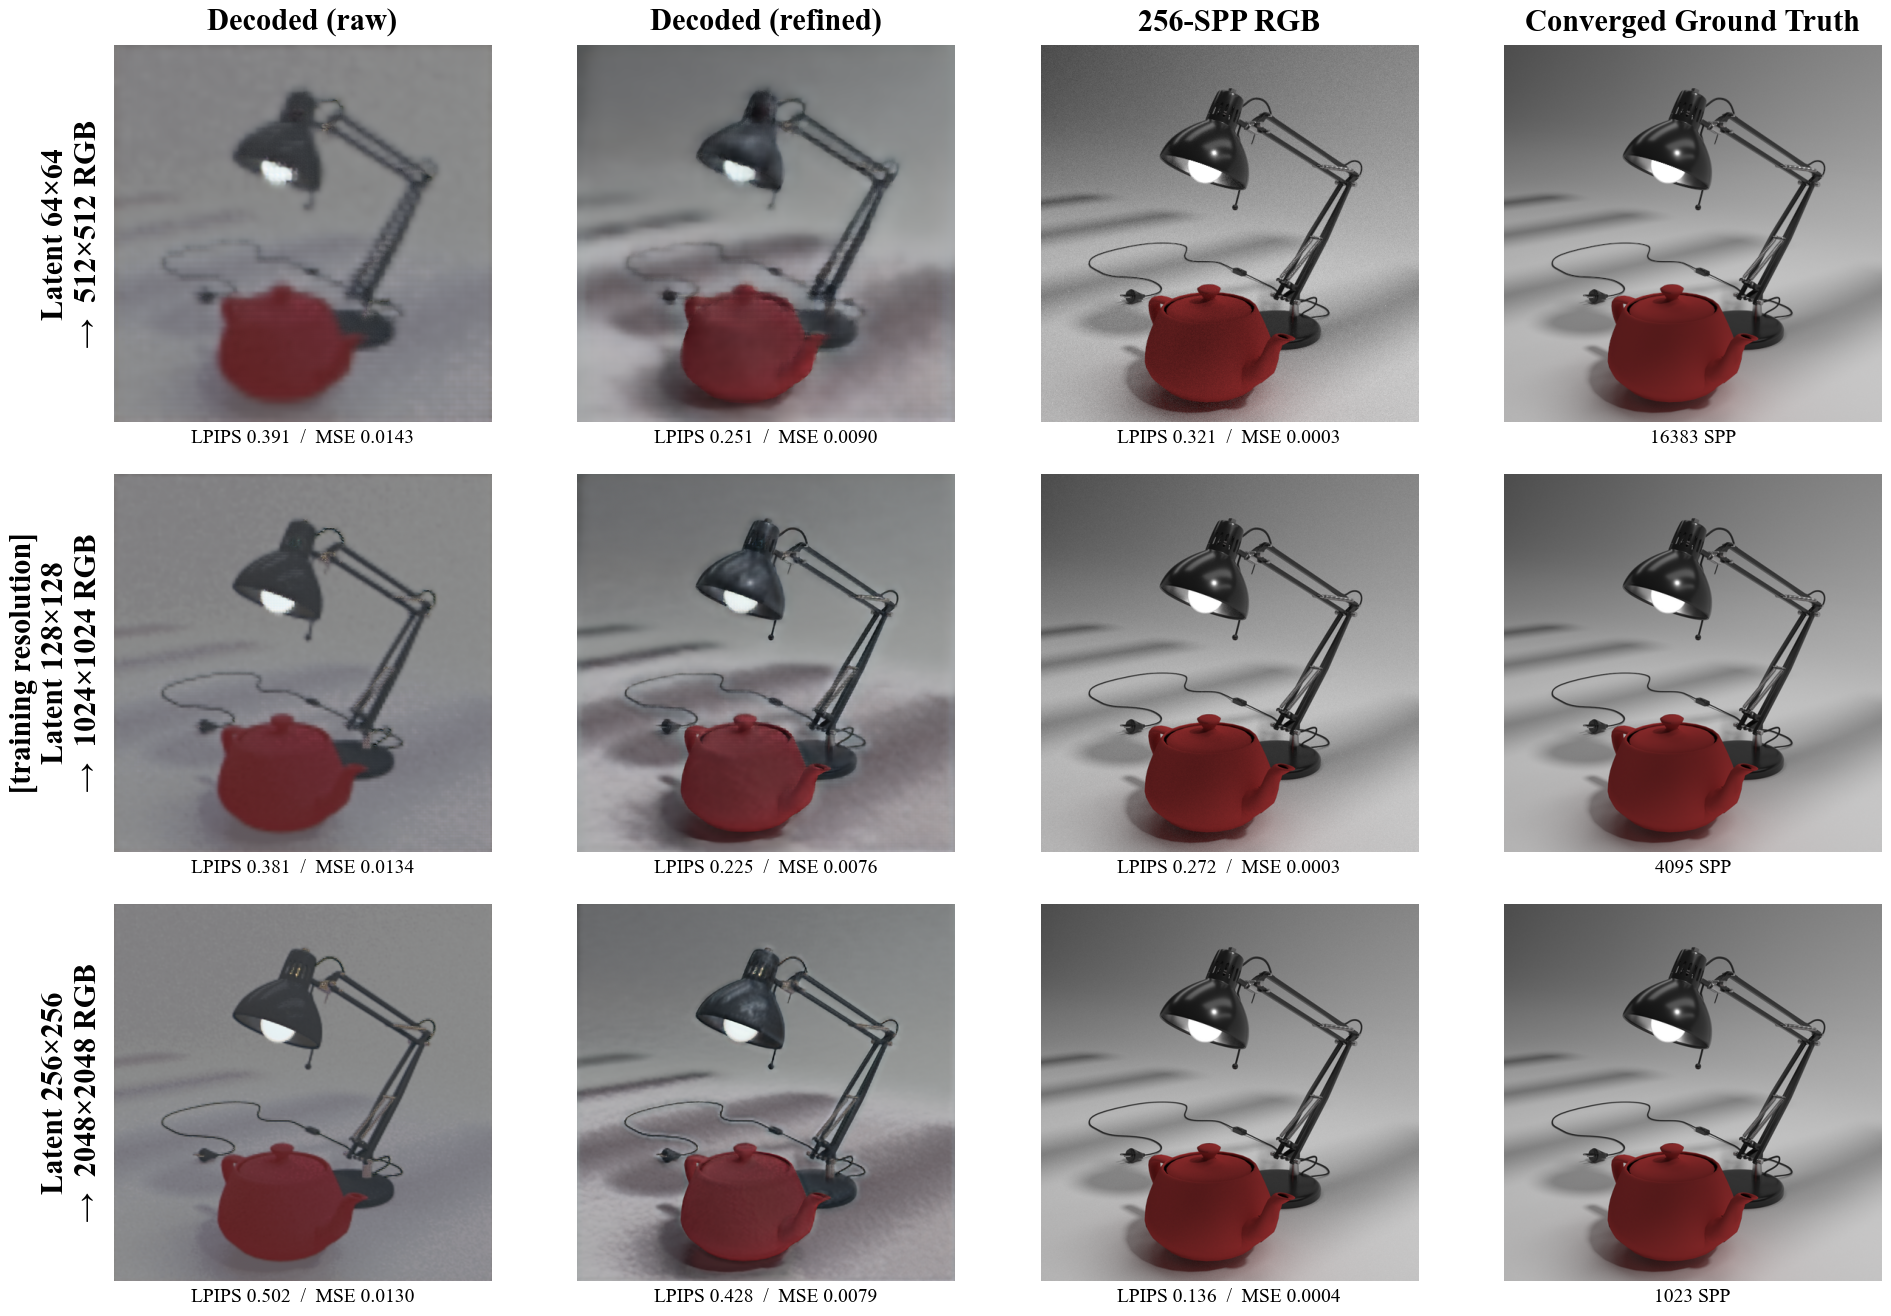

In [8]:
from utils.img_utils import compute_image_metrics

TITLE_SIZE = 22

plt.rcParams.update({
    "font.family":     "serif",
    "font.serif":      ["Times New Roman", "Times"],
    "font.size":       18,
    "axes.titlesize":  TITLE_SIZE,
    "axes.labelsize":  18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

DISP        = 512
TRAINED_RES = latent_res  # 128

def to_display(t: torch.Tensor) -> np.ndarray:
    if t.ndim == 4:
        img = t[0].permute(1, 2, 0)
    elif t.ndim == 3 and t.shape[0] in (1, 3, 4):
        img = t.permute(1, 2, 0)
    else:
        img = t
    img = img[..., :3].clamp(0, 1).numpy()
    if max(img.shape[:2]) > DISP:
        from PIL import Image as PILImage
        pil = PILImage.fromarray((img * 255).astype(np.uint8))
        img = np.array(pil.resize((DISP, DISP), PILImage.LANCZOS)) / 255.0
    return img

def metrics_label(test: torch.Tensor, ref: torch.Tensor | None) -> str:
    if ref is None:
        return "(no converged ref)"
    if test is None:
        return "(OOM)"
    try:
        m, _ = compute_image_metrics(ref, test)
        return f"LPIPS {m['lpips']:.3f}  /  MSE {m['mse']:.4f}"
    except Exception as e:
        return f"(metrics error: {e})"

def row_ylabel(r: int, rgb_res: int) -> str:
    tag = "[training resolution]\n" if r == TRAINED_RES else ""
    return f"{tag}Latent {r}×{r}\n→  {rgb_res}×{rgb_res} RGB"

col_titles = [
    "Decoded (raw)",
    "Decoded (refined)",
    f"{GT_SPP}-SPP RGB",
    "Converged Ground Truth",
]

valid = [(r, results[r]) for r in RESOLUTIONS if results.get(r) is not None]

print('Super-resolution image grid metrics (raw MSE over [0,1]):')
fig, axes = plt.subplots(len(valid), 4, figsize=(20, 4.5 * len(valid)), squeeze=False)

for row, (r, res) in enumerate(valid):
    ref      = res["ref"]
    ref_spp  = res["ref_spp"]
    panels   = [res["decoded_raw"], res["decoded_ref"], res["rgb"], ref]
    xlabels  = [
        metrics_label(res["decoded_raw"], ref),
        metrics_label(res["decoded_ref"], ref),
        metrics_label(res["rgb"],         ref),
        f"{ref_spp} SPP",
    ]

    print(f'  {r}×{r}→{res["rgb_res"]}×{res["rgb_res"]}:')
    for col, (tensor, xlabel) in enumerate(zip(panels, xlabels)):
        ax = axes[row, col]
        if tensor is None:
            ax.text(0.5, 0.5, "OOM", ha="center", va="center",
                    fontsize=20, transform=ax.transAxes)
        else:
            ax.imshow(to_display(tensor))
            if col < 3:
                print(f'    {col_titles[col]}: {xlabel}')

        if row == 0:
            ax.set_title(col_titles[col], fontsize=TITLE_SIZE, fontweight="bold", pad=10)

        ax.set_xlabel(xlabel, labelpad=5, fontsize=14)

        if col == 0:
            ax.set_ylabel(row_ylabel(r, res["rgb_res"]),
                          fontsize=TITLE_SIZE, fontweight="bold", labelpad=8)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.tight_layout()
plt.savefig("notebooks/superresolution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()